# LDA (complement to EDA)

LDA is just for topic exploration, not used for classification afterwards

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import umap

import pyLDAvis
import pyLDAvis.gensim_models as gensim_models

from gensim.models import LdaModel, CoherenceModel, LdaMulticore
from gensim.corpora import Dictionary

from rital_nlp_project.common.utils import load_clean_data
from rital_nlp_project.common.notebook_utils import init_notebook
from rital_nlp_project.presidents.utils import concat_seq_by_class

init_notebook()

**Notes**
- `LdaMulticore` produces non-deterministic results due to parallelism (even with `random_state` set). Can switch to `LDAModel` but results are worse (in terms of pyLDAvis), many overlapping circles.
- Most likely, we will use LDA just as a visualization technique, not as an improvement to algorithms.

- Coherence score is kinda low ***(why?)*** -> visual inspection. The goal is to avoid many overlapping circles

### Movies

In [20]:
texts_movies, classes_movies = load_clean_data("../Dataset/clean/movies_clean.parquet")

In [21]:
from rital_nlp_project.movies.models_config import min_df, max_df
texts_tokens = [text.split() for text in texts_movies]

dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=min_df, no_above=max_df)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/gensim/models/ldamodel.py:720: RuntimeWarning: overflow encountered in dot
  gammad = self.alpha + expElogthetad * np.dot(cts / phinorm, expElogbetad.T)
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/gensim/models/ldamodel.py:720: RuntimeWarning: overflow encountered in dot
  gammad = self.alpha + expElogthetad * np.dot(cts / phinorm, expElogbetad.T)
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/gensim/models/ldamodel.py:720: RuntimeWarning: overflow encountered in dot
  gammad = self.alpha + expElogthetad * np.dot(cts / phinorm, expElogbetad.T)
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/gensim/models/ldamodel.py:720: RuntimeWarning: overflow encountered in dot
  gammad = self.alpha + expElogthetad * np.dot(cts / phinorm, expElogbetad.T)
/Users/bsh20

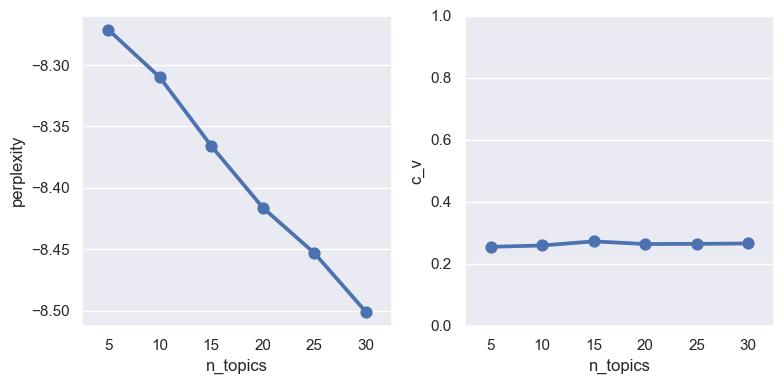

In [4]:
params = {
    "n_topics" : np.arange(5, 35, 5),
    "perplexity" : [],
    "c_v" : []
}

for k in params["n_topics"]:
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42, chunksize=100, per_word_topics=True)
    coherence_model = CoherenceModel(model=lda_model, texts=texts_tokens, dictionary=dictionary, coherence='c_v')
    params["perplexity"].append(lda_model.log_perplexity(corpus))
    c_v = coherence_model.get_coherence()
    params["c_v"].append(coherence_model.get_coherence())

df = pd.DataFrame(data=params)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
sns.pointplot(data=df, x="n_topics", y="perplexity", ax=ax1)
sns.pointplot(data=df, x="n_topics", y="c_v", ax=ax2)
ax2.set_ylim(0, 1)
plt.tight_layout()

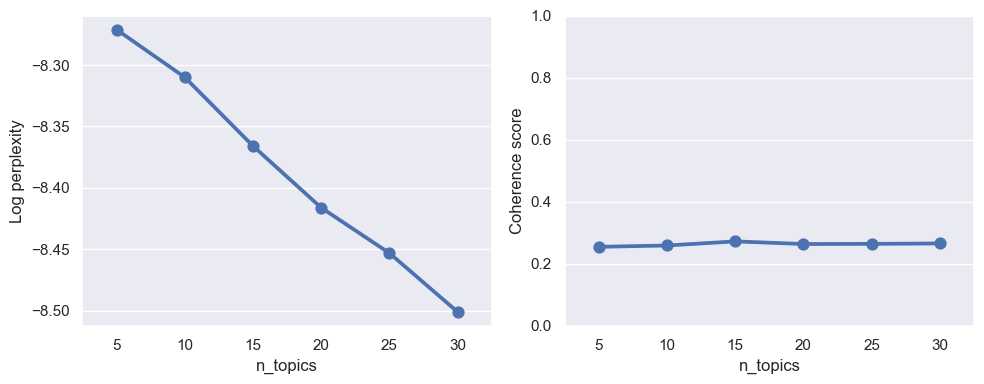

In [5]:
df = pd.DataFrame(data=params)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.pointplot(data=df, x="n_topics", y="perplexity", ax=ax1)
sns.pointplot(data=df, x="n_topics", y="c_v", ax=ax2)
ax2.set_ylim(0, 1)
ax2.set_ylabel("Coherence score")
ax1.set_ylabel("Log perplexity")

plt.tight_layout()
fig.savefig("plots/movies_lda_eval.pdf", bbox_inches="tight")

In [24]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=10, passes=10, random_state=42, chunksize=100, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.save_html(vis, "plots/movies_lda_10topics.html")
pyLDAvis.display(vis)

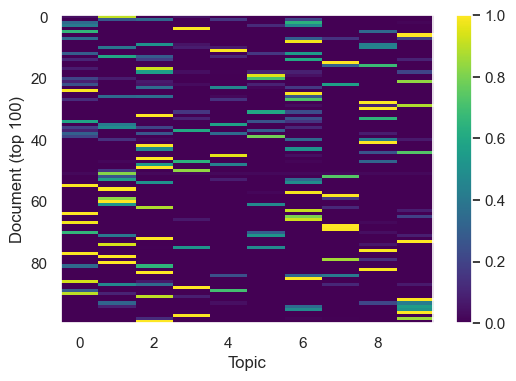

In [25]:
doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
                              for bow in corpus])

limit = 100
fig = plt.figure(figsize=(6, 4))
plt.imshow(doc_topic_matrix[:limit, :], aspect="auto", vmin=0, vmax=1, cmap="viridis")
plt.xlabel("Topic")
plt.ylabel(f"Document (top {limit})")
plt.colorbar()
plt.grid(False)
fig.savefig("plots/movies_lda_matrix.pdf", bbox_inches="tight")

In [26]:
dominant_topics = doc_topic_matrix.argmax(axis=1)
umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
embedding = umap_.fit_transform(doc_topic_matrix)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


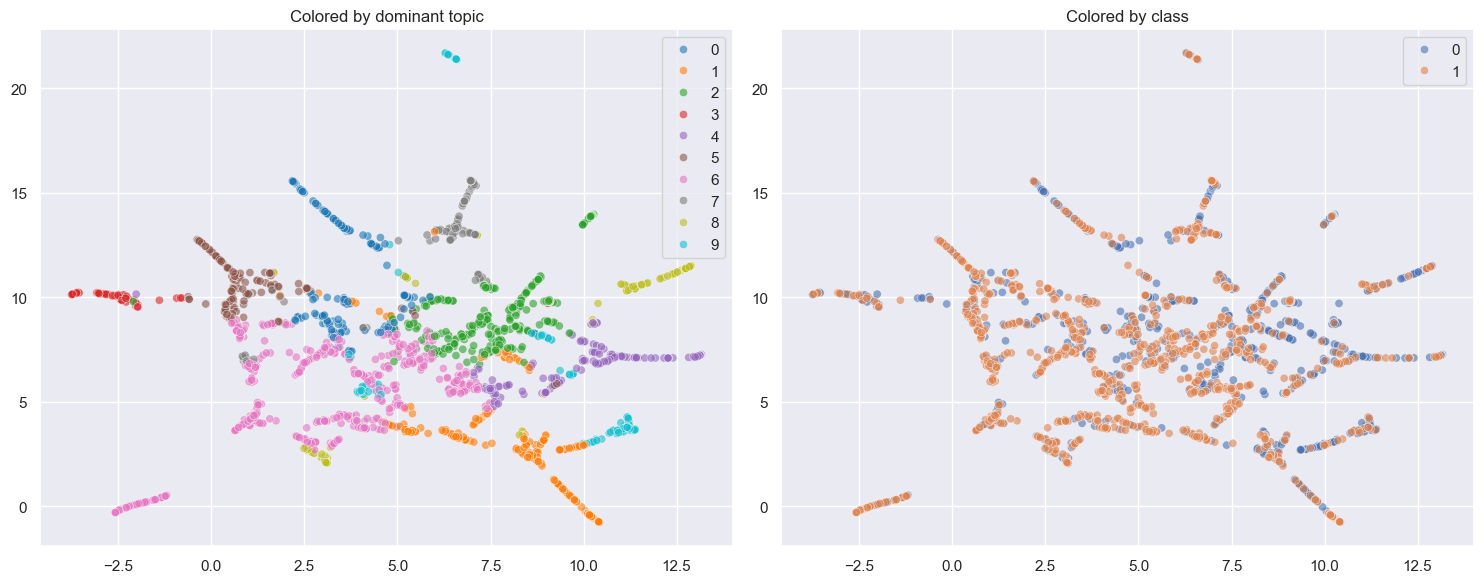

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.set_title("Colored by dominant topic")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=dominant_topics,
    palette="tab10",       
    alpha=0.6,
    ax=ax1
)
ax2.set_title("Colored by class")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=classes_movies,       
    alpha=0.6,
    ax=ax2
)

plt.tight_layout()
fig.savefig("plots/movies_lda_umap.pdf", bbox_inches="tight")

### Presidents

**Notes**

- LDA struggles with very short documents (the case here, since very likely the whole docs were cut into phrases). Indeed, if LDA (e.g. 5 topics) is examined on `texts_pres`, topics are hard to interpret. However, if LDA is run on `texts_pres_concat` (much longer documents), topics are much more meaningful

- **To test** : since for predictions topics would be inferred per phrase , check if performance is ok

In [10]:
from rital_nlp_project.presidents.models_config import min_df, max_df
texts_pres, classes_pres = load_clean_data("../Dataset/clean/presidents_clean.parquet")

# Can fix n = None as well
texts_pres_concat, classes_pres_concat = concat_seq_by_class(texts_pres, classes_pres, n=20)

#### LDA on `texts_pres`

LDA is supposed to struggle on very short documents (normal since LDA's hypothesis : each document is a mix of topics) -> the case here, most relevant terms are not explanatory 

In [11]:
texts_tokens = [text.split() for text in texts_pres]
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=min_df, no_above=max_df)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=15, passes=10, random_state=42, chunksize=50, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.save_html(vis, "plots/pres_bad_lda_15topics.html")
pyLDAvis.display(vis)

#### LDA on `texts_pres_concat`

Use LDA instead on concatenated phrases (with max fixed)

In [12]:
texts_tokens = [text.split() for text in texts_pres_concat]
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=min_df, no_above=max_df)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

In [13]:
params = {
    "n_topics" : np.arange(5, 35, 5),
    "perplexity" : [],
    "c_v" : []
}

for k in params["n_topics"]:
    lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=k, passes=10, random_state=42, chunksize=100, per_word_topics=True)
    coherence_model = CoherenceModel(model=lda_model, texts=texts_tokens, dictionary=dictionary, coherence='c_v')
    params["perplexity"].append(lda_model.log_perplexity(corpus))
    c_v = coherence_model.get_coherence()
    params["c_v"].append(coherence_model.get_coherence())
    print(k, c_v)

5 0.36020210782505624
10 0.4105793325889442
15 0.39891336724316084
20 0.38172907313037496
25 0.37375793163241994


/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/gensim/models/ldamodel.py:720: RuntimeWarning: overflow encountered in dot
  gammad = self.alpha + expElogthetad * np.dot(cts / phinorm, expElogbetad.T)
/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/gensim/models/ldamodel.py:720: RuntimeWarning: overflow encountered in dot
  gammad = self.alpha + expElogthetad * np.dot(cts / phinorm, expElogbetad.T)


30 0.3765129456645738


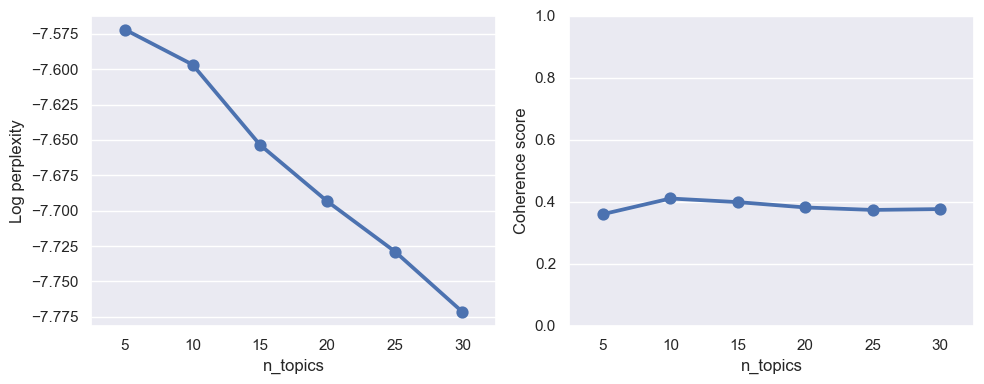

In [14]:
df = pd.DataFrame(data=params)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
sns.pointplot(data=df, x="n_topics", y="perplexity", ax=ax1)
sns.pointplot(data=df, x="n_topics", y="c_v", ax=ax2)
ax2.set_ylim(0, 1)
ax2.set_ylabel("Coherence score")
ax1.set_ylabel("Log perplexity")

plt.tight_layout()
fig.savefig("plots/pres_lda_eval.pdf", bbox_inches="tight")

In [15]:
lda_model = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=15, passes=20, random_state=42, chunksize=100, per_word_topics=True)
pyLDAvis.enable_notebook(local=True)
vis = gensim_models.prepare(lda_model, corpus, dictionary)

pyLDAvis.save_html(vis, "plots/pres_lda_15topics.html")
pyLDAvis.display(vis)

#### UMAP on concatenated phrases

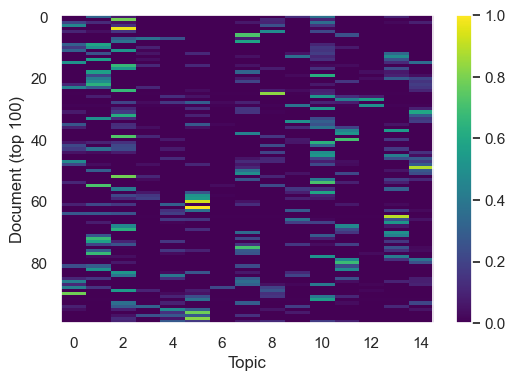

In [16]:
doc_topic_matrix = np.array([[prob for _, prob in lda_model.get_document_topics(bow, minimum_probability=0)]
                              for bow in corpus])

limit = 100
fig = plt.figure(figsize=(6, 4))
plt.imshow(doc_topic_matrix[:limit, :], aspect="auto", vmin=0, vmax=1, cmap="viridis")
plt.xlabel("Topic")
plt.ylabel(f"Document (top {limit})")
plt.colorbar()
plt.grid(False)

fig.savefig("plots/pres_lda_matrix.pdf", bbox_inches="tight")

In [17]:
dominant_topics = doc_topic_matrix.argmax(axis=1)

umap_ = umap.UMAP(n_components=2, random_state=42, metric="hellinger")
embedding = umap_.fit_transform(doc_topic_matrix)

/Users/bsh2022/Study/master_ue/rital/RITAL-NLP-project/.venv-313/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


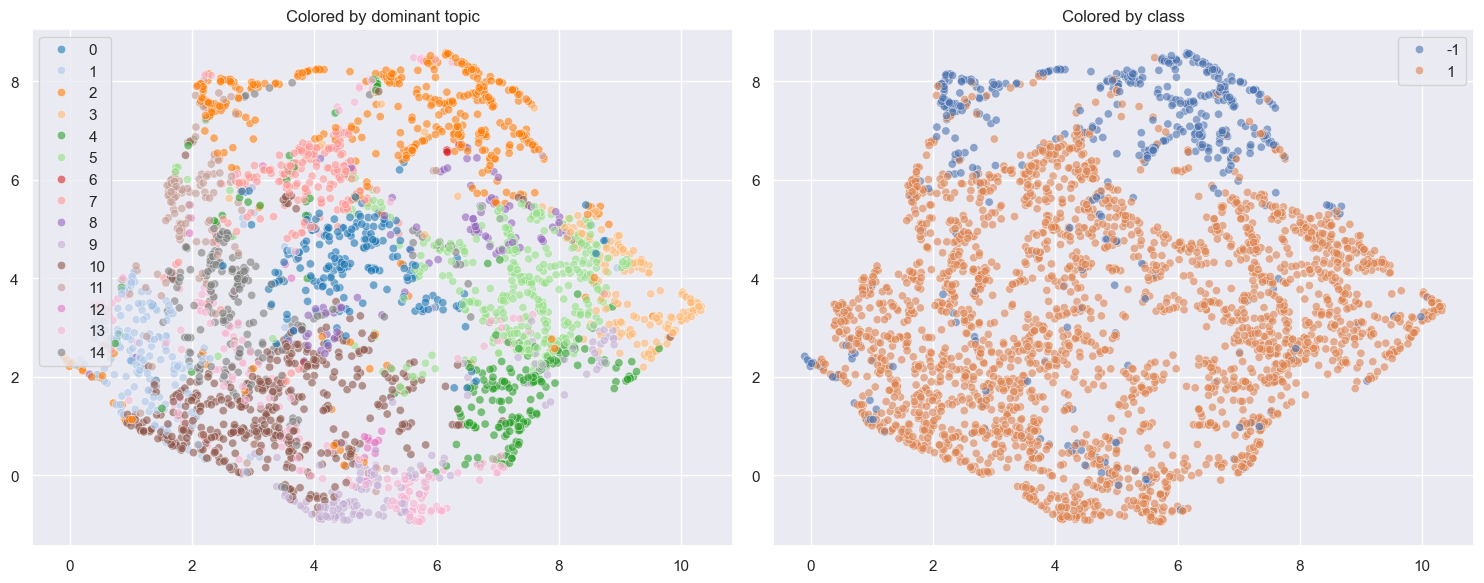

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.set_title("Colored by dominant topic")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=dominant_topics[:],
    palette="tab20",       
    alpha=0.6,
    ax=ax1
)
ax2.set_title("Colored by class")
sns.scatterplot(
    x=embedding[:, 0],
    y=embedding[:, 1],
    hue=classes_pres_concat[:],    
    palette="deep",
    alpha=0.6,
    ax=ax2
)

plt.tight_layout()
fig.savefig("plots/pres_lda_umap.pdf", bbox_inches="tight")